In [1]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

df = pd.read_csv("student_scores.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df = df.dropna()

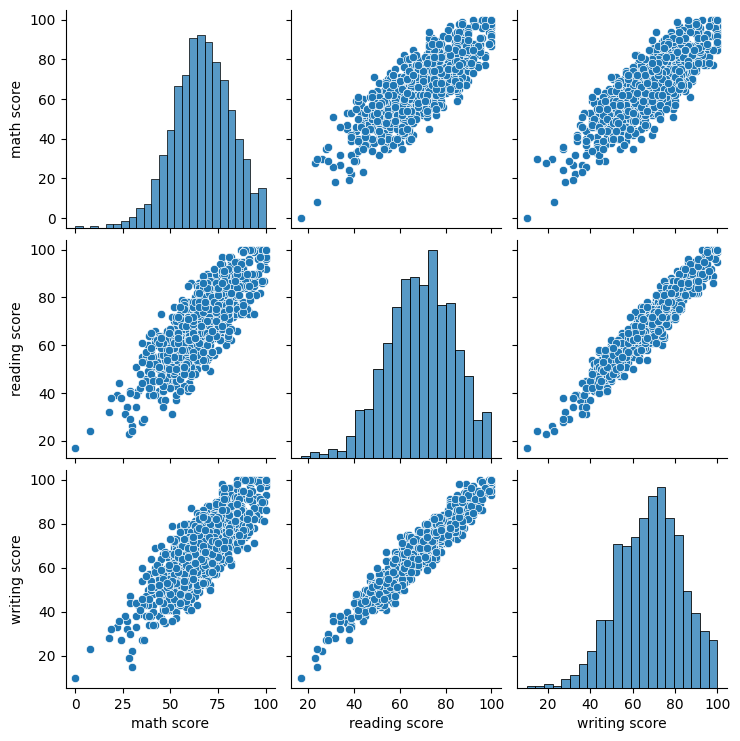

In [7]:
sns.pairplot(df)
plt.show()

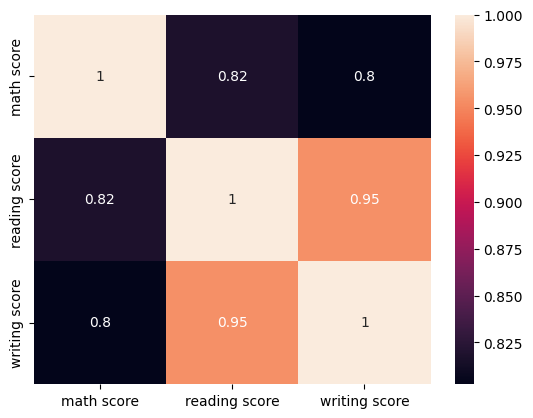

In [20]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [10]:
X = df.drop("math score", axis=1)
y = df["math score"]

In [11]:
X = pd.get_dummies(X)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 4.4147233759961075


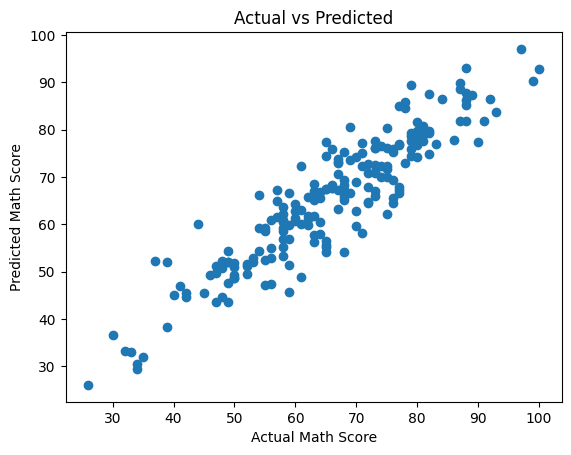

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted")
plt.show()

In [21]:
model.predict(X_test.iloc[:1])

array([47.43883152])

In [22]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

from sklearn.metrics import mean_absolute_error

print("Decision Tree MAE:", mean_absolute_error(y_test, dt_pred))

Decision Tree MAE: 6.13


In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

Random Forest MAE: 5.0116966666666665


In [25]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor()
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
print("KNN MAE:", mean_absolute_error(y_test, knn_pred))

KNN MAE: 5.901999999999999


In [26]:
results = {
    "Linear Regression": mean_absolute_error(y_test, y_pred),
    "Decision Tree": mean_absolute_error(y_test, dt_pred),
    "Random Forest": mean_absolute_error(y_test, rf_pred),
    "KNN": mean_absolute_error(y_test, knn_pred)
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "MAE"])
results_df

,Model,MAE
0,Linear Regression,4.414723
1,Decision Tree,6.130000
2,Random Forest,5.011697
3,KNN,5.902000


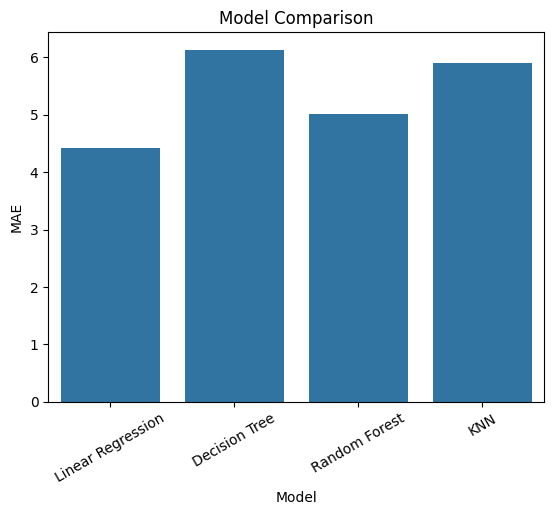

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="MAE", data=results_df)
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()

In [28]:
results_df = results_df.sort_values(by="MAE")
results_df

,Model,MAE
0,Linear Regression,4.414723
2,Random Forest,5.011697
3,KNN,5.902000
1,Decision Tree,6.130000
